In [1]:
#Import libraries
import os
import pandas as pd
import mrmr
from sklearn.model_selection import train_test_split
from mrmr import mrmr_classif
import numpy as np 

In [2]:
# Create directories
os.makedirs("./train_data", exist_ok=True)
os.makedirs("./test_data", exist_ok=True)
os.makedirs("./results/mRMR_plots", exist_ok=True)

# CHP vs Control

In [3]:
#Import dataset
raw_data = pd.read_csv("./results/Subsetted_corrected_matrix/Merged_cHPvsCtrl_Subsetted_Expression.csv", index_col = 0).T
metadata = pd.read_csv("./results/xCell_results/Merged_metadata_HP_Ctrl.csv", index_col=1)
metadata = metadata.drop(metadata.columns[[0]], axis=1)

In [4]:
print(raw_data.shape)
raw_data.head()

(245, 1724)


,SAMD11,PLEKHN1,PERM1,TTLL10,TNFRSF18,ANKRD65,TMEM52,CFAP74,PLCH2,TP73,...,PNMA5,PNMA3,BGN,DUSP9,PNCK,SSR4,L1CAM,AVPR2,DDX3Y,CDY2A
GSM5583910,7.449767,7.314961,5.025731,5.496565,6.575717,8.734203,4.211557,4.623835,6.779698,4.294027,...,3.078324,4.014043,9.205990,3.148007,4.280999,14.091411,4.899937,4.734440,9.162089,3.176484
GSM5583911,6.812216,5.686948,4.965188,6.999614,7.570494,8.857000,4.221778,7.485924,7.083254,5.886954,...,3.078324,4.836297,7.791175,3.991014,3.942294,12.824098,4.960323,3.668797,8.765897,3.137029
GSM5583912,7.633127,6.397101,5.234857,5.318490,5.996415,8.592982,4.731583,5.949264,7.436273,4.537890,...,3.078324,4.014043,8.299205,3.148007,4.506922,13.670242,4.337306,4.647608,8.994416,3.588330
GSM5583913,7.531725,6.231734,5.732200,5.143184,6.700243,8.927841,4.589815,4.338588,7.164680,3.097412,...,3.078324,5.316547,8.623783,3.148007,4.752929,13.695814,4.204250,4.572123,9.325351,3.214563
GSM5583914,8.339009,5.507224,5.391517,6.068559,4.355536,9.084700,3.812876,5.549050,5.661555,3.935961,...,3.078324,4.014043,10.958351,3.148007,4.825393,13.403828,5.662659,4.167453,8.838288,3.583752


In [5]:
metadata.head()

,condition
sample,
GSM5583910,Control
GSM5583911,Control
GSM5583912,Control
GSM5583913,Control
GSM5583914,Control


In [6]:
merged_df = raw_data.join(metadata)
merged_df.head()

,SAMD11,PLEKHN1,PERM1,TTLL10,TNFRSF18,ANKRD65,TMEM52,CFAP74,PLCH2,TP73,...,PNMA3,BGN,DUSP9,PNCK,SSR4,L1CAM,AVPR2,DDX3Y,CDY2A,condition
GSM5583910,7.449767,7.314961,5.025731,5.496565,6.575717,8.734203,4.211557,4.623835,6.779698,4.294027,...,4.014043,9.205990,3.148007,4.280999,14.091411,4.899937,4.734440,9.162089,3.176484,Control
GSM5583911,6.812216,5.686948,4.965188,6.999614,7.570494,8.857000,4.221778,7.485924,7.083254,5.886954,...,4.836297,7.791175,3.991014,3.942294,12.824098,4.960323,3.668797,8.765897,3.137029,Control
GSM5583912,7.633127,6.397101,5.234857,5.318490,5.996415,8.592982,4.731583,5.949264,7.436273,4.537890,...,4.014043,8.299205,3.148007,4.506922,13.670242,4.337306,4.647608,8.994416,3.588330,Control
GSM5583913,7.531725,6.231734,5.732200,5.143184,6.700243,8.927841,4.589815,4.338588,7.164680,3.097412,...,5.316547,8.623783,3.148007,4.752929,13.695814,4.204250,4.572123,9.325351,3.214563,Control
GSM5583914,8.339009,5.507224,5.391517,6.068559,4.355536,9.084700,3.812876,5.549050,5.661555,3.935961,...,4.014043,10.958351,3.148007,4.825393,13.403828,5.662659,4.167453,8.838288,3.583752,Control


In [9]:
X = merged_df.iloc[:, 0:1724]
y = merged_df.iloc[:,-1]

print(X.head())
print(y.head())

print(X.shape)

              SAMD11   PLEKHN1     PERM1    TTLL10  TNFRSF18   ANKRD65  \
GSM5583910  7.449767  7.314961  5.025731  5.496565  6.575717  8.734203   
GSM5583911  6.812216  5.686948  4.965188  6.999614  7.570494  8.857000   
GSM5583912  7.633127  6.397101  5.234857  5.318490  5.996415  8.592982   
GSM5583913  7.531725  6.231734  5.732200  5.143184  6.700243  8.927841   
GSM5583914  8.339009  5.507224  5.391517  6.068559  4.355536  9.084700   

              TMEM52    CFAP74     PLCH2      TP73  ...     PNMA5     PNMA3  \
GSM5583910  4.211557  4.623835  6.779698  4.294027  ...  3.078324  4.014043   
GSM5583911  4.221778  7.485924  7.083254  5.886954  ...  3.078324  4.836297   
GSM5583912  4.731583  5.949264  7.436273  4.537890  ...  3.078324  4.014043   
GSM5583913  4.589815  4.338588  7.164680  3.097412  ...  3.078324  5.316547   
GSM5583914  3.812876  5.549050  5.661555  3.935961  ...  3.078324  4.014043   

                  BGN     DUSP9      PNCK       SSR4     L1CAM     AVPR2  \
GSM5

In [10]:
raw_data.describe()

,SAMD11,PLEKHN1,PERM1,TTLL10,TNFRSF18,ANKRD65,TMEM52,CFAP74,PLCH2,TP73,...,PNMA5,PNMA3,BGN,DUSP9,PNCK,SSR4,L1CAM,AVPR2,DDX3Y,CDY2A
count,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,...,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000
mean,7.294299,5.650014,5.467450,6.418124,6.434045,9.381251,5.066839,6.637860,7.176351,5.244744,...,3.450501,4.790042,8.219176,3.648202,5.474728,13.050423,5.169261,4.450140,5.837370,3.159231
std,0.995237,0.751833,0.806719,1.125308,0.928646,0.576555,1.060047,1.107962,1.077290,0.964738,...,0.441154,0.652677,1.812036,0.609669,1.121071,0.665212,0.730770,0.955457,2.843834,0.559135
min,4.637059,4.031734,3.742542,4.010452,2.460940,7.445257,2.703782,3.424253,4.619807,2.885356,...,2.718739,3.587774,3.579635,2.772856,3.254306,11.302347,3.344510,1.919833,2.019694,2.557144
25%,6.681667,5.133172,4.882633,5.603240,5.851166,9.018623,4.340435,5.812753,6.404452,4.576746,...,3.126415,4.306310,7.056293,3.206092,4.679673,12.617793,4.670809,3.890695,3.160155,2.801738
50%,7.339886,5.686948,5.391727,6.421796,6.423044,9.400235,5.005441,6.657768,7.116037,5.123694,...,3.451064,4.689810,7.750223,3.549212,5.243526,13.053247,5.140602,4.391105,4.302677,3.216272
75%,8.064862,6.138264,6.055115,7.125822,7.068903,9.823158,5.816490,7.341418,7.835260,5.881583,...,3.745585,5.213499,8.946825,4.024345,6.255777,13.403828,5.610959,4.899441,8.584835,3.216272
max,9.982995,7.675177,7.606206,9.684981,8.530322,10.664450,8.236842,9.807913,10.192662,7.958646,...,4.528392,7.109256,14.338597,6.234087,9.286805,15.912341,7.445889,9.258236,11.496016,6.054006


In [11]:
# 70:30 dataset split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)

train = pd.concat([X_train, y_train], axis=1)
train.to_csv('./train_data/cHP_Ctrl_train_data.csv', index = True)

test = pd.concat([X_test, y_test], axis=1)
test.to_csv('./test_data/cHP_Ctrl_test_data.csv', index=True)

## mRMR: Cumulative Feature Score vs No. of genes

In [12]:
## mRMR with 70-30 train-test split

mrmr_all_genes = mrmr_classif(
    X=X_train,
    y=y_train,
    K=X_train.shape[1],    # selects all genes to create the plot
    relevance='f',         # or 'rf' or 'ks'
    redundancy='c',        # Pearson correlation
    denominator='mean',    # or 'max'
    cat_features=None,
    return_scores=True,    # to inspect relevance and redundancy scores
    n_jobs=-1,             # use all CPUs
    show_progress=True     # show tqdm bar
)

gene_list, relevance_scores, redundancy_scores = mrmr_all_genes

print("Top 50 selected genes:")
print(gene_list[:50])

100%|███████████████████████████████████████████████████████████████████████████████| 1724/1724 [01:10<00:00, 24.41it/s]

Top 50 selected genes:
['ADRA1A', 'BTLA', 'BTNL9', 'PTPRB', 'AFF3', 'FLT4', 'GPX3', 'KLRG2', 'MME', 'ARHGAP6', 'CHRM3', 'PEAR1', 'NEBL', 'BAAT', 'SEMA6A', 'PTPRQ', 'HIF3A', 'ADAMTS7', 'GRIA1', 'DENND3', 'LIN7A', 'WWC2', 'CXCL13', 'ZNF792', 'RAPGEF4', 'COMP', 'RNF182', 'CDH19', 'CYP3A5', 'RAPGEF5', 'NKD1', 'GCOM1', 'DLC1', 'TEK', 'IL17RB', 'FAXDC2', 'MAP3K15', 'CASKIN2', 'SGCG', 'TAL1', 'PPFIBP1', 'COL17A1', 'FNDC1', 'CDH13', 'SLC5A9', 'SLC19A3', 'CORO6', 'FHL2', 'FDCSP', 'LIFR']


In [13]:
print(type(relevance_scores), np.shape(relevance_scores))
print(type(redundancy_scores), np.shape(redundancy_scores))

<class 'pandas.core.series.Series'> (1724,)
<class 'pandas.core.frame.DataFrame'> (1724, 1724)


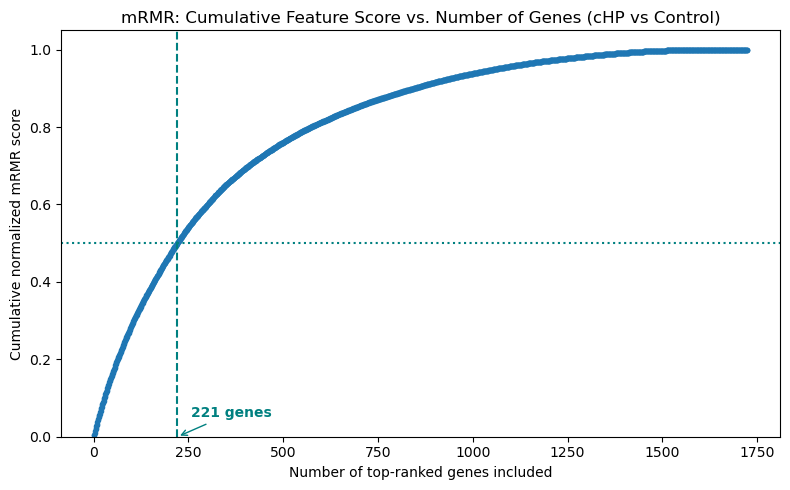

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Extract scores in ranking order
relevance = [relevance_scores[gene] for gene in gene_list]

redundancy = []
for i, gene in enumerate(gene_list):
    if i == 0:
        redundancy.append(0)
    else:
        prev_genes = gene_list[:i]
        mean_corr = redundancy_scores.loc[gene, prev_genes].mean()
        redundancy.append(mean_corr)

# Final mRMR score
mrmr_scores = np.array(relevance) - np.array(redundancy)

# Normalize
mrmr_scores = mrmr_scores / np.max(mrmr_scores)

# Cumulative normalized score
cumulative_scores = np.cumsum(mrmr_scores) / np.sum(mrmr_scores)

# X-axis = all genes
x = np.arange(1, len(mrmr_scores) + 1)

# Plot full curve
plt.figure(figsize=(8, 5))
plt.plot(x, cumulative_scores, 'o-', markersize=3)

# --- NEW ADDITIONS FOR INTERCEPTS ---
cutoff = 0.5
plt.axhline(cutoff, color='teal', linestyle=':')

# 1. Find the x-value where the cumulative score first reaches or exceeds the cutoff
intercept_idx = np.argmax(cumulative_scores >= cutoff)
intercept_x = x[intercept_idx]

# 2. Draw vertical line across the entire vertical space
plt.axvline(x=intercept_x, color='teal', linestyle='--')

# 3. Annotate the exact intercept value explicitly on the plot
plt.annotate(f"{intercept_x} genes", 
             xy=(intercept_x, 0), 
             xytext=(intercept_x + (len(x) * 0.02), 0.05), # Offsets text slightly right and up
             color='teal', 
             fontweight='bold',
             arrowprops=dict(arrowstyle="->", color='teal'))
# ------------------------------------

plt.title("mRMR: Cumulative Feature Score vs. Number of Genes (cHP vs Control)")
plt.xlabel("Number of top-ranked genes included")
plt.ylabel("Cumulative normalized mRMR score")

# Ensure the y-axis starts at 0 so the vertical line touches the bottom cleanly
plt.ylim(bottom=0) 

plt.savefig("./results/mRMR_plots/cHPvsCtrl_Cum_Feature_score_vs_genes.png", dpi = 600)
plt.tight_layout()
plt.show()

Now we extract the number of genes at which our cumulative normalized mRMR score is 0.5

In [15]:
# 1. Select the top 221 genes from the list
top_genes = gene_list[:221]

# 2. Define the output file path
output_file = './train_data/cHP_Ctrl_top_mrmr_genes.txt'

# 3. Write the genes to the .txt file
with open(output_file, 'w') as file:
    for gene in top_genes:
        file.write(f"{gene}\n")

print(f"Successfully saved {len(top_genes)} genes to {output_file}")

Successfully saved 221 genes to ./train_data/cHP_Ctrl_top_mrmr_genes.txt


# CHP vs IPF

In [16]:
#Import dataset
raw_data = pd.read_csv("./results/Subsetted_corrected_matrix/Merged_cHPvsIPF_Subsetted_Expression.csv", index_col = 0).T
metadata = pd.read_csv("./results/xCell_results/Merged_metadata_HP_IPF.csv", index_col=1)
metadata = metadata.drop(metadata.columns[[0]], axis=1)

In [17]:
print(raw_data.shape)
raw_data.head()

(261, 380)


,HES2,SPSB1,ANGPTL7,LCK,CDCA8,POU3F1,TMCO2,RIMS3,CITED4,ST3GAL3,...,CSAG1,MAGEA2,CSAG3,PNMA5,BGN,AVPR2,TBL1Y,PRKY,DDX3Y,KDM5D
GSM5583934,7.941768,6.245396,5.779875,8.986917,7.244428,6.426775,5.180703,3.738309,8.502533,8.407612,...,5.378421,5.333773,7.207440,4.552155,7.632317,6.372380,2.944602,7.054258,6.997955,9.168083
GSM5583935,8.096678,6.220269,3.440041,7.835505,5.573754,5.726521,2.776583,3.217877,8.326210,6.302822,...,2.666641,3.927540,3.913166,3.784507,9.331885,5.860821,3.838324,7.970716,7.948112,10.140648
GSM5583936,7.835205,5.646966,3.717726,8.404662,5.968016,5.975759,2.776583,3.435449,8.420044,6.028177,...,2.865447,4.393826,3.546322,3.288306,8.579374,5.101450,3.586747,7.393197,7.324861,9.603281
GSM5583937,8.578773,5.021066,5.343180,9.158810,7.264927,6.415723,4.926557,2.661526,8.844259,7.171221,...,5.131201,5.195069,7.057824,4.142027,6.585280,5.313256,3.836714,7.268897,6.444469,8.540154
GSM5583938,6.886363,6.599954,4.330187,7.721333,5.754650,5.560225,3.873492,2.471523,8.102457,6.377833,...,4.334248,4.224776,5.397069,3.687343,8.596039,4.527255,3.631494,6.672913,7.518386,8.941671


In [18]:
metadata.value_counts()

condition
IPF          143
HP           118
Name: count, dtype: int64

In [19]:
merged_df = raw_data.join(metadata)
merged_df.head()

,HES2,SPSB1,ANGPTL7,LCK,CDCA8,POU3F1,TMCO2,RIMS3,CITED4,ST3GAL3,...,MAGEA2,CSAG3,PNMA5,BGN,AVPR2,TBL1Y,PRKY,DDX3Y,KDM5D,condition
GSM5583934,7.941768,6.245396,5.779875,8.986917,7.244428,6.426775,5.180703,3.738309,8.502533,8.407612,...,5.333773,7.207440,4.552155,7.632317,6.372380,2.944602,7.054258,6.997955,9.168083,HP
GSM5583935,8.096678,6.220269,3.440041,7.835505,5.573754,5.726521,2.776583,3.217877,8.326210,6.302822,...,3.927540,3.913166,3.784507,9.331885,5.860821,3.838324,7.970716,7.948112,10.140648,HP
GSM5583936,7.835205,5.646966,3.717726,8.404662,5.968016,5.975759,2.776583,3.435449,8.420044,6.028177,...,4.393826,3.546322,3.288306,8.579374,5.101450,3.586747,7.393197,7.324861,9.603281,HP
GSM5583937,8.578773,5.021066,5.343180,9.158810,7.264927,6.415723,4.926557,2.661526,8.844259,7.171221,...,5.195069,7.057824,4.142027,6.585280,5.313256,3.836714,7.268897,6.444469,8.540154,HP
GSM5583938,6.886363,6.599954,4.330187,7.721333,5.754650,5.560225,3.873492,2.471523,8.102457,6.377833,...,4.224776,5.397069,3.687343,8.596039,4.527255,3.631494,6.672913,7.518386,8.941671,HP


In [20]:
X = merged_df.iloc[:, 0:380]
y = merged_df.iloc[:,-1]

print(X.head())
print(y.head())

print(X.shape)

                HES2     SPSB1   ANGPTL7       LCK     CDCA8    POU3F1  \
GSM5583934  7.941768  6.245396  5.779875  8.986917  7.244428  6.426775   
GSM5583935  8.096678  6.220269  3.440041  7.835505  5.573754  5.726521   
GSM5583936  7.835205  5.646966  3.717726  8.404662  5.968016  5.975759   
GSM5583937  8.578773  5.021066  5.343180  9.158810  7.264927  6.415723   
GSM5583938  6.886363  6.599954  4.330187  7.721333  5.754650  5.560225   

               TMCO2     RIMS3    CITED4   ST3GAL3  ...     CSAG1    MAGEA2  \
GSM5583934  5.180703  3.738309  8.502533  8.407612  ...  5.378421  5.333773   
GSM5583935  2.776583  3.217877  8.326210  6.302822  ...  2.666641  3.927540   
GSM5583936  2.776583  3.435449  8.420044  6.028177  ...  2.865447  4.393826   
GSM5583937  4.926557  2.661526  8.844259  7.171221  ...  5.131201  5.195069   
GSM5583938  3.873492  2.471523  8.102457  6.377833  ...  4.334248  4.224776   

               CSAG3     PNMA5       BGN     AVPR2     TBL1Y      PRKY  \
GSM558

In [21]:
raw_data.describe()

,HES2,SPSB1,ANGPTL7,LCK,CDCA8,POU3F1,TMCO2,RIMS3,CITED4,ST3GAL3,...,CSAG1,MAGEA2,CSAG3,PNMA5,BGN,AVPR2,TBL1Y,PRKY,DDX3Y,KDM5D
count,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,...,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000
mean,6.450963,6.883356,3.411830,6.486667,5.029582,3.979512,3.250677,3.352565,7.368704,5.811000,...,2.712004,2.931311,3.434027,2.939719,8.270360,3.962429,3.426584,6.380373,6.080276,7.644204
std,0.868069,1.663611,0.912319,1.255376,0.975132,0.978316,0.844274,0.568972,0.832313,0.921361,...,0.760213,0.882267,1.322114,0.550347,1.948702,1.212243,0.958052,2.295270,2.763706,3.207855
min,4.232554,3.577498,1.165925,3.638289,2.018609,1.889547,2.111516,1.850762,5.612561,3.026384,...,1.897726,1.640032,1.989034,2.137769,3.178098,1.451503,1.752833,1.435800,0.309277,0.847993
25%,5.863501,5.709531,2.909487,5.563336,4.531098,3.303843,2.776583,3.060807,6.756369,5.241528,...,2.219955,2.334535,2.468399,2.513252,7.058573,3.045647,2.539080,4.119350,3.089792,4.521390
50%,6.410468,6.835405,2.991727,6.403882,5.094966,3.921158,2.985353,3.079687,7.259849,5.759392,...,2.759032,3.015978,3.098905,2.913260,7.944715,3.858143,3.648283,7.585195,7.324861,9.424338
75%,6.956863,8.054924,3.741249,7.286338,5.625655,4.513949,3.808882,3.650378,7.933588,6.362794,...,2.759032,3.015978,3.881656,3.316505,9.145748,4.546094,4.233194,8.308243,8.320820,10.314998
max,10.287584,11.484558,6.482475,9.340559,7.367564,6.436539,6.168881,5.947151,9.979532,9.226884,...,5.596425,5.789634,8.822314,4.552155,14.516101,9.370122,5.601036,9.529693,10.671570,11.941311


In [22]:
# 70:30 dataset split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)

train = pd.concat([X_train, y_train], axis=1)
train.to_csv('./train_data/cHP_IPF_train_data.csv', index = True)

test = pd.concat([X_test, y_test], axis=1)
test.to_csv('./test_data/cHP_IPF_test_data.csv', index=True)

## mRMR: Cumulative Feature Score vs No. of genes

In [23]:
## mRMR with 70-30 train-test split

mrmr_all_genes = mrmr_classif(
    X=X_train,
    y=y_train,
    K=X_train.shape[1],    # selects all genes to create the plot
    relevance='f',         # or 'rf' or 'ks'
    redundancy='c',        # Pearson correlation
    denominator='mean',    # or 'max'
    cat_features=None,
    return_scores=True,    # to inspect relevance and redundancy scores
    n_jobs=-1,             # use all CPUs
    show_progress=True     # show tqdm bar
)

gene_list, relevance_scores, redundancy_scores = mrmr_all_genes

print("Top 50 selected genes:")
print(gene_list[:50])

100%|█████████████████████████████████████████████████████████████████████████████████| 380/380 [00:09<00:00, 39.82it/s]

Top 50 selected genes:
['RNF208', 'CALHM6', 'NKX6-2', 'PRKY', 'COL5A3', 'OLIG1', 'CXCL8', 'SULT1E1', 'IRF4', 'GPR25', 'MROH6', 'BORCS6', 'ARGLU1', 'ITGAV', 'A1BG', 'CITED4', 'TDO2', 'ZNF443', 'TMIGD2', 'ZGLP1', 'CEMP1', 'ZNF668', 'ADAMTS1', 'DDX3Y', 'ARID5B', 'INPP5J', 'DCANP1', 'ANAPC11', 'RDH10', 'MYRF', 'OCEL1', 'FSTL1', 'TIGD5', 'CSAG3', 'LIF', 'CCDC6', 'KDM5D', 'GNA14', 'KIF12', 'SLC16A11', 'TNFSF12-TNFSF13', 'COL4A1', 'FOXS1', 'SDHAF1', 'NOXO1', 'NMRK2', 'DNASE1L2', 'TNNT1', 'FATE1', 'PCP2']


In [24]:
print(type(relevance_scores), np.shape(relevance_scores))
print(type(redundancy_scores), np.shape(redundancy_scores))

<class 'pandas.core.series.Series'> (380,)
<class 'pandas.core.frame.DataFrame'> (380, 380)


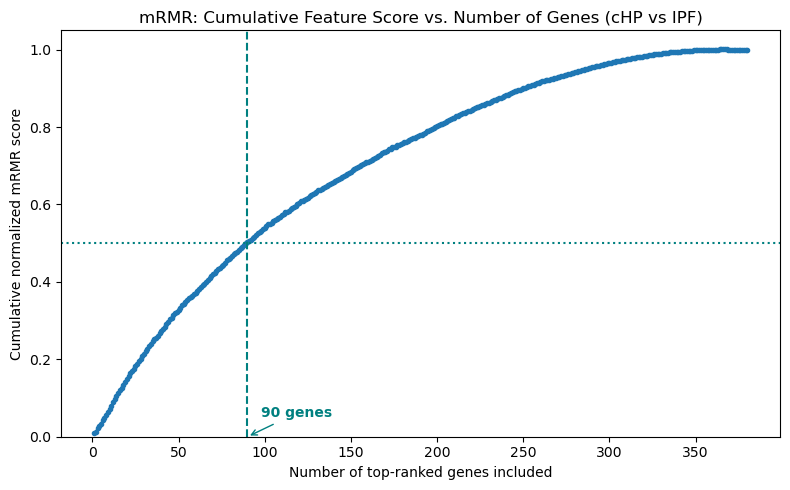

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Extract scores in ranking order
relevance = [relevance_scores[gene] for gene in gene_list]

redundancy = []
for i, gene in enumerate(gene_list):
    if i == 0:
        redundancy.append(0)
    else:
        prev_genes = gene_list[:i]
        mean_corr = redundancy_scores.loc[gene, prev_genes].mean()
        redundancy.append(mean_corr)

# Final mRMR score
mrmr_scores = np.array(relevance) - np.array(redundancy)

# Normalize
mrmr_scores = mrmr_scores / np.max(mrmr_scores)

# Cumulative normalized score
cumulative_scores = np.cumsum(mrmr_scores) / np.sum(mrmr_scores)

# X-axis = all genes
x = np.arange(1, len(mrmr_scores) + 1)

# Plot full curve
plt.figure(figsize=(8, 5))
plt.plot(x, cumulative_scores, 'o-', markersize=3)

# --- NEW ADDITIONS FOR INTERCEPTS ---
cutoff = 0.5
plt.axhline(cutoff, color='teal', linestyle=':')

# 1. Find the x-value where the cumulative score first reaches or exceeds the cutoff
intercept_idx = np.argmax(cumulative_scores >= cutoff)
intercept_x = x[intercept_idx]

# 2. Draw vertical line across the entire vertical space
plt.axvline(x=intercept_x, color='teal', linestyle='--')

# 3. Annotate the exact intercept value explicitly on the plot
plt.annotate(f"{intercept_x} genes", 
             xy=(intercept_x, 0), 
             xytext=(intercept_x + (len(x) * 0.02), 0.05), # Offsets text slightly right and up
             color='teal', 
             fontweight='bold',
             arrowprops=dict(arrowstyle="->", color='teal'))
# ------------------------------------

plt.title("mRMR: Cumulative Feature Score vs. Number of Genes (cHP vs IPF)")
plt.xlabel("Number of top-ranked genes included")
plt.ylabel("Cumulative normalized mRMR score")

# Ensure the y-axis starts at 0 so the vertical line touches the bottom cleanly
plt.ylim(bottom=0) 

plt.savefig("./results/mRMR_plots/cHPvsIPF_Cum_Feature_score_vs_genes.png", dpi = 600)
plt.tight_layout()
plt.show()

Now we extract the number of genes at which our cumulative normalized mRMR score is 0.5

In [26]:
# 1. Select the top 90 genes from the list
top_genes = gene_list[:90]

# 2. Define the output file path
output_file = './train_data/cHP_IPF_top_mrmr_genes.txt'

# 3. Write the genes to the .txt file
with open(output_file, 'w') as file:
    for gene in top_genes:
        file.write(f"{gene}\n")

print(f"Successfully saved {len(top_genes)} genes to {output_file}")

Successfully saved 90 genes to ./train_data/cHP_IPF_top_mrmr_genes.txt


# IPF vs Control

In [27]:
#Import dataset
raw_data = pd.read_csv("./results/Subsetted_corrected_matrix/Merged_IPFvsCtrl_Subsetted_Expression.csv", index_col = 0).T
metadata = pd.read_csv("./results/xCell_results/Merged_metadata_IPF_Ctrl.csv", index_col=1)
metadata = metadata.drop(metadata.columns[[0]], axis=1)

In [28]:
print(raw_data.shape)
raw_data.head()

(270, 1643)


,SAMD11,PLEKHN1,TTLL10,TNFRSF18,CFAP74,PLCH2,MMEL1,TP73,AJAP1,HES2,...,HMGB3,CSAG2,CSAG3,CETN2,DUSP9,PNCK,TKTL1,TSPY2,TSPY3,CDY2A
GSM5583910,7.163701,7.125776,5.193747,6.255022,4.526073,6.831881,7.647459,3.721658,6.096077,5.337852,...,8.475270,4.095646,4.050210,10.838541,2.059583,4.796446,7.055239,0.872529,1.957402,1.803993
GSM5583911,6.479567,5.351387,6.807649,7.363303,7.557479,7.122987,6.520682,5.722008,5.576221,6.263029,...,8.978702,2.721395,2.749335,10.771136,3.349858,4.173067,5.885511,1.674780,1.877912,1.724998
GSM5583912,7.332637,6.173868,4.966393,5.505308,6.072796,7.502517,8.247510,4.044815,6.765196,6.346244,...,8.080924,3.153789,4.503222,10.549288,2.059583,5.169375,7.080405,2.272754,2.182859,2.457964
GSM5583913,7.252047,6.007627,4.755310,6.411644,4.141579,7.242352,8.803020,1.867980,7.338088,5.675673,...,8.918983,3.518631,3.504004,10.684888,2.059583,5.578705,6.722432,0.872529,1.696397,1.872014
GSM5583914,8.035984,5.155644,5.870254,3.022447,5.659119,5.596624,7.779366,3.216538,6.119294,5.541204,...,7.239589,2.846258,2.867531,10.446521,2.059583,5.696391,5.088916,1.744022,1.650277,2.464205


In [29]:
metadata.value_counts()

condition
IPF          143
Control      127
Name: count, dtype: int64

In [30]:
merged_df = raw_data.join(metadata)
merged_df.head()

,SAMD11,PLEKHN1,TTLL10,TNFRSF18,CFAP74,PLCH2,MMEL1,TP73,AJAP1,HES2,...,CSAG2,CSAG3,CETN2,DUSP9,PNCK,TKTL1,TSPY2,TSPY3,CDY2A,condition
GSM5583910,7.163701,7.125776,5.193747,6.255022,4.526073,6.831881,7.647459,3.721658,6.096077,5.337852,...,4.095646,4.050210,10.838541,2.059583,4.796446,7.055239,0.872529,1.957402,1.803993,Control
GSM5583911,6.479567,5.351387,6.807649,7.363303,7.557479,7.122987,6.520682,5.722008,5.576221,6.263029,...,2.721395,2.749335,10.771136,3.349858,4.173067,5.885511,1.674780,1.877912,1.724998,Control
GSM5583912,7.332637,6.173868,4.966393,5.505308,6.072796,7.502517,8.247510,4.044815,6.765196,6.346244,...,3.153789,4.503222,10.549288,2.059583,5.169375,7.080405,2.272754,2.182859,2.457964,Control
GSM5583913,7.252047,6.007627,4.755310,6.411644,4.141579,7.242352,8.803020,1.867980,7.338088,5.675673,...,3.518631,3.504004,10.684888,2.059583,5.578705,6.722432,0.872529,1.696397,1.872014,Control
GSM5583914,8.035984,5.155644,5.870254,3.022447,5.659119,5.596624,7.779366,3.216538,6.119294,5.541204,...,2.846258,2.867531,10.446521,2.059583,5.696391,5.088916,1.744022,1.650277,2.464205,Control


In [31]:
X = merged_df.iloc[:, 0:1643]
y = merged_df.iloc[:,-1]

print(X.head())
print(y.head())

print(X.shape)

              SAMD11   PLEKHN1    TTLL10  TNFRSF18    CFAP74     PLCH2  \
GSM5583910  7.163701  7.125776  5.193747  6.255022  4.526073  6.831881   
GSM5583911  6.479567  5.351387  6.807649  7.363303  7.557479  7.122987   
GSM5583912  7.332637  6.173868  4.966393  5.505308  6.072796  7.502517   
GSM5583913  7.252047  6.007627  4.755310  6.411644  4.141579  7.242352   
GSM5583914  8.035984  5.155644  5.870254  3.022447  5.659119  5.596624   

               MMEL1      TP73     AJAP1      HES2  ...     HMGB3     CSAG2  \
GSM5583910  7.647459  3.721658  6.096077  5.337852  ...  8.475270  4.095646   
GSM5583911  6.520682  5.722008  5.576221  6.263029  ...  8.978702  2.721395   
GSM5583912  8.247510  4.044815  6.765196  6.346244  ...  8.080924  3.153789   
GSM5583913  8.803020  1.867980  7.338088  5.675673  ...  8.918983  3.518631   
GSM5583914  7.779366  3.216538  6.119294  5.541204  ...  7.239589  2.846258   

               CSAG3      CETN2     DUSP9      PNCK     TKTL1     TSPY2  \
GSM55

In [32]:
raw_data.describe()

,SAMD11,PLEKHN1,TTLL10,TNFRSF18,CFAP74,PLCH2,MMEL1,TP73,AJAP1,HES2,...,HMGB3,CSAG2,CSAG3,CETN2,DUSP9,PNCK,TKTL1,TSPY2,TSPY3,CDY2A
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,...,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000
mean,7.526897,5.497722,6.464329,6.429196,6.737626,7.304021,6.560836,5.018986,4.798775,5.780183,...,8.834420,2.086441,2.425988,10.978120,2.651960,4.956193,4.054694,1.539708,1.598114,1.730774
std,1.202640,0.882923,1.426109,0.985162,1.350775,1.198172,1.256610,1.333085,1.233167,0.924540,...,0.797390,0.885758,1.034636,0.618141,0.954090,1.109885,1.285022,0.554350,0.607810,0.537965
min,4.221651,2.986189,3.203245,3.022447,2.780470,4.119041,3.520951,1.496282,0.526018,2.167973,...,5.974303,1.189810,1.161794,10.032139,0.908942,2.212013,0.736213,0.872529,0.772439,0.626406
25%,6.691973,5.025060,5.505361,5.791120,5.730632,6.386301,5.621859,4.084172,3.920955,5.198829,...,8.286378,1.195140,1.363341,10.556706,2.059583,4.222120,3.236699,1.291732,1.375137,1.425989
50%,7.531164,5.577410,6.520447,6.440258,6.730155,7.304107,6.578207,5.050871,4.563787,5.865226,...,8.904143,1.995857,2.350698,10.836776,2.380966,4.982555,4.004360,1.477442,1.542883,1.655876
75%,8.286640,6.115673,7.415170,7.133856,7.644027,8.202462,7.584748,5.886706,5.504599,6.388965,...,9.346742,2.723523,3.062756,11.209686,3.291968,5.611018,4.784450,1.477442,1.542883,1.693181
max,11.184520,7.720363,10.637437,8.622392,10.798197,10.367254,9.330117,8.479671,8.381686,8.786968,...,10.984036,4.923317,5.799168,13.573066,5.221518,8.748797,9.544248,4.229511,5.890577,3.831638


In [33]:
# 70:30 dataset split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)

train = pd.concat([X_train, y_train], axis=1)
train.to_csv('./train_data/IPF_Ctrl_train_data.csv', index = True)

test = pd.concat([X_test, y_test], axis=1)
test.to_csv('./test_data/IPF_Ctrl_test_data.csv', index=True)

## mRMR: Cumulative Feature Score vs No. of genes

In [34]:
## mRMR with 70-30 train-test split

mrmr_all_genes = mrmr_classif(
    X=X_train,
    y=y_train,
    K=X_train.shape[1],    # selects all genes to create the plot
    relevance='f',         # or 'rf' or 'ks'
    redundancy='c',        # Pearson correlation
    denominator='mean',    # or 'max'
    cat_features=None,
    return_scores=True,    # to inspect relevance and redundancy scores
    n_jobs=-1,             # use all CPUs
    show_progress=True     # show tqdm bar
)

gene_list, relevance_scores, redundancy_scores = mrmr_all_genes

print("Top 50 selected genes:")
print(gene_list[:50])

100%|███████████████████████████████████████████████████████████████████████████████| 1643/1643 [01:08<00:00, 24.03it/s]

Top 50 selected genes:
['KLRG2', 'ADRA1A', 'ITLN2', 'BAAT', 'EPB41L5', 'FHL2', 'MYRF', 'MAP3K15', 'CPAMD8', 'IGFL2', 'FAM167A', 'COMP', 'LIMCH1', 'AFF3', 'NOTCH4', 'TINCR', 'MS4A15', 'GPR87', 'HSD17B6', 'CXCL13', 'CDH3', 'ADRB2', 'GRIA1', 'KANK3', 'CHRM3', 'AGER', 'DIO2', 'ARHGEF26', 'ARHGAP6', 'CTHRC1', 'OTULINL', 'COL10A1', 'RTKN2', 'MME', 'UNC13B', 'SPRR1A', 'RNF182', 'BTNL9', 'HPCAL1', 'COL17A1', 'OLFML2A', 'NEBL', 'MVB12B', 'PDZD2', 'MAP3K21', 'DAPK2', 'AATK', 'LIN7A', 'LAMA3', 'RGS9BP']


In [35]:
print(type(relevance_scores), np.shape(relevance_scores))
print(type(redundancy_scores), np.shape(redundancy_scores))

<class 'pandas.core.series.Series'> (1643,)
<class 'pandas.core.frame.DataFrame'> (1643, 1643)


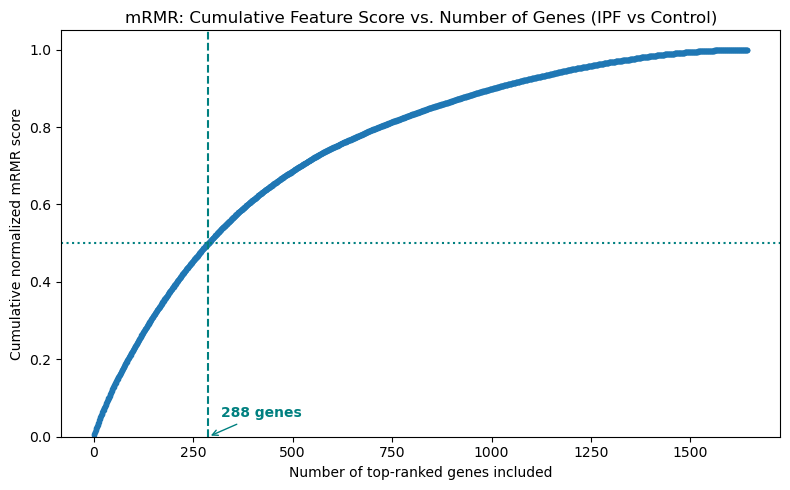

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Extract scores in ranking order
relevance = [relevance_scores[gene] for gene in gene_list]

redundancy = []
for i, gene in enumerate(gene_list):
    if i == 0:
        redundancy.append(0)
    else:
        prev_genes = gene_list[:i]
        mean_corr = redundancy_scores.loc[gene, prev_genes].mean()
        redundancy.append(mean_corr)

# Final mRMR score
mrmr_scores = np.array(relevance) - np.array(redundancy)

# Normalize
mrmr_scores = mrmr_scores / np.max(mrmr_scores)

# Cumulative normalized score
cumulative_scores = np.cumsum(mrmr_scores) / np.sum(mrmr_scores)

# X-axis = all genes
x = np.arange(1, len(mrmr_scores) + 1)

# Plot full curve
plt.figure(figsize=(8, 5))
plt.plot(x, cumulative_scores, 'o-', markersize=3)

# --- NEW ADDITIONS FOR INTERCEPTS ---
cutoff = 0.5
plt.axhline(cutoff, color='teal', linestyle=':')

# 1. Find the x-value where the cumulative score first reaches or exceeds the cutoff
intercept_idx = np.argmax(cumulative_scores >= cutoff)
intercept_x = x[intercept_idx]

# 2. Draw vertical line across the entire vertical space
plt.axvline(x=intercept_x, color='teal', linestyle='--')

# 3. Annotate the exact intercept value explicitly on the plot
plt.annotate(f"{intercept_x} genes", 
             xy=(intercept_x, 0), 
             xytext=(intercept_x + (len(x) * 0.02), 0.05), # Offsets text slightly right and up
             color='teal', 
             fontweight='bold',
             arrowprops=dict(arrowstyle="->", color='teal'))
# ------------------------------------

plt.title("mRMR: Cumulative Feature Score vs. Number of Genes (IPF vs Control)")
plt.xlabel("Number of top-ranked genes included")
plt.ylabel("Cumulative normalized mRMR score")

# Ensure the y-axis starts at 0 so the vertical line touches the bottom cleanly
plt.ylim(bottom=0) 

plt.savefig("./results/mRMR_plots/IPFvsCtrl_Cum_Feature_score_vs_genes.png", dpi = 600)
plt.tight_layout()
plt.show()

Now we extract the number of genes at which our cumulative normalized mRMR score is 0.5

In [37]:
# 1. Select the top 288 genes from the list
top_genes = gene_list[:288]

# 2. Define the output file path
output_file = './train_data/IPF_Ctrl_top_mrmr_genes.txt'

# 3. Write the genes to the .txt file
with open(output_file, 'w') as file:
    for gene in top_genes:
        file.write(f"{gene}\n")

print(f"Successfully saved {len(top_genes)} genes to {output_file}")

Successfully saved 288 genes to ./train_data/IPF_Ctrl_top_mrmr_genes.txt
